CHUẨN BỊ CÁC TÀI NGUYÊN CẦN THIẾT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# cài đặt cấu hình cần thiết
!pip install ultralytics
!pip install -U sahi
!pip install tensorflow matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.9 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import shutil
import os
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import pandas as pd
import numpy as np
import cv2
import numpy as np
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


ĐIỀU CHỈNH VIỆC CHỌN DATASET VÀ MODEL ĐỂ TRAIN TẠI ĐÂY

In [4]:
#tùy biến cấu hình train

#tên model muốn train
MODEL_NAME = "yolo26n-seg.pt"

#tên dataset muốn train
DATASET_NAME = "35_special_images_segmentation.v1i.yolov8"

#tên lần train lưu lại trong thư mục content/runs/detect/Rice_seed_detection/{tên}, ưu tiên kết hợp tên dataset và model
TRAINED_RESULT_NAME = "35_special_images_segmentation.v1i.yolov8_v1_trained"

#thay đổi tùy theo tài khoản
PRIVATE_SOURCE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/LOBBY/MAIN_SOURCES/"

#folder chứa các model
MODELS_PATH = f"{PRIVATE_SOURCE_PATH}MODELS/"

#folder chứa dataset
DATAS_PATH = f"{PRIVATE_SOURCE_PATH}DATASETS/"

#folder chứa các loại hình ảnh để test thử cho các mục đích khác nhau
TEST_IMAGES_PATH = f"{PRIVATE_SOURCE_PATH}TEST_IMAGES/"

#folder chứa hình ảnh dùng để detect thử sau khi train sahi hoặc yolo
DETECTABLE_TEST_IMAGES_PATH = f"{TEST_IMAGES_PATH}DETECTABLE_TEST_IMAGES/"

#folder chứa các hình ảnh hạt lúa đã được cắt ra để thử phân lớp (classification)
CROPPED_TEST_IMAGES_PATH = f"{TEST_IMAGES_PATH}CROPPED_TEST_IMAGES/"

#folder chứa các hình ảnh gốc để test toàn bộ luồng làm việc
ORIGINAL_RANDOM_TEST_IMAGES_PATH = f"{TEST_IMAGES_PATH}ORIGINAL_RANDOM_TEST_IMAGES/"

#folder chứa kết quả sau khi train nằm trên content tạm
TRAINED_RESULTS_PATH = f"/content/runs/segment/yolo26_rice_seg/{TRAINED_RESULT_NAME}/"

#folder sẽ được chứa kết quả sau khi train nằm trong drive
TRAINED_RESULTS_DESTINATION_PATH = f"{PRIVATE_SOURCE_PATH}RESULTS/{TRAINED_RESULT_NAME}/"



#khai báo cấu trúc lưu lại các kết quả của sahi

#nơi chứa các hình ảnh được detect nhưng chưa được cắt
SAHI_DETECTION_CONTENT_PATH = f"/content/SAHI/{TRAINED_RESULT_NAME}/DETECTED_OBJECTS/"

#nơi chứa các hình ảnh được detect đẫ được cắt
CROPPED_SAHI_DETECTION_CONTENT_PATH = f"/content/SAHI/{TRAINED_RESULT_NAME}/CROPPED_DETECTED_OBJECTS/"

#nơi chứa cả 2 loại hình ảnh đã cắt và chưa cắt
SAHI_DETECTION_RESULT_CONTENT_PATH = f"/content/SAHI/{TRAINED_RESULT_NAME}/"

#nơi lưu kết quả sahi
SAHI_DETECTION_RESULT_DESTINATION_PATH = f"{PRIVATE_SOURCE_PATH}DETECTED_OBJECTS/{TRAINED_RESULT_NAME}/"

#dành cho full test
#nơi chứa các hình ảnh được detect nhưng chưa được cắt
FULL_TEST_DETECTION_CONTENT_PATH = f"/content/FULL_TEST/{TRAINED_RESULT_NAME}/DETECTED_OBJECTS/"

#nơi chứa các hình ảnh được detect đẫ được cắt
CROPPED_FULL_TEST_DETECTION_CONTENT_PATH = f"/content/FULL_TEST/{TRAINED_RESULT_NAME}/CROPPED_DETECTED_OBJECTS/"

#nơi chứa cả 2 loại hình ảnh đã cắt và chưa cắt
FULL_TEST_DETECTION_RESULT_CONTENT_PATH = f"/content/FULL_TEST/{TRAINED_RESULT_NAME}/"


XỬ LÝ VỚI VẬT ĐỰNG VÀ THỬ VỚI KÉT QUẢ

In [5]:
# module xử lý ellipsoid
THICKNESS_RATIO = {
    "hat_nguyen":     0.9,
    "hat_khuyet_tat": 0.9,
    "undefined":      0.55,
}

def compute_ellipsoid_volume(local_mask_uint8, label):
    contours, _ = cv2.findContours(local_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    ellipse_params = None

    if len(contours) == 0 or max(contours, key=cv2.contourArea).shape[0] < 5:
        h, w = local_mask_uint8.shape[:2]
        a, b = max(w, h) / 2, min(w, h) / 2
        fit_method = "BoundingRect (fallback)"
    else:
        largest       = max(contours, key=cv2.contourArea)
        ellipse_cv    = cv2.fitEllipse(largest)
        ellipse_params = ellipse_cv
        MA, ma        = ellipse_cv[1]
        a, b          = MA / 2, ma / 2
        fit_method = "fitEllipse (cv2)"

    k      = THICKNESS_RATIO.get(label, 0.55)
    c      = a * k
    volume = (4 / 3) * math.pi * a * b * c

    return {
        "vol_px3": volume,
        "a_px": a,
        "b_px": b,
        "c_px": c,
        "k_factor": k,
        "fit": fit_method,
        "ellipse_params": ellipse_params
    }

def draw_ellipse_overlay(crop_bgr, local_mask_uint8, ell_result):
    vis = cv2.cvtColor(crop_bgr.copy(), cv2.COLOR_BGR2RGB)
    contours, _ = cv2.findContours(local_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis, contours, -1, (0, 220, 80), 1)

    ep = ell_result["ellipse_params"]
    if ep is not None:
        center = (int(ep[0][0]), int(ep[0][1]))
        axes   = (int(ep[1][0] / 2), int(ep[1][1] / 2))
        angle  = ep[2]
        cv2.ellipse(vis, center, axes, angle, 0, 360, (255, 80, 0), 2)

        angle_rad = math.radians(angle)
        ax_end = (int(center[0] + ell_result["a_px"] * math.cos(angle_rad)), int(center[1] + ell_result["a_px"] * math.sin(angle_rad)))
        bx_end = (int(center[0] - ell_result["b_px"] * math.sin(angle_rad)), int(center[1] + ell_result["b_px"] * math.cos(angle_rad)))
        cv2.arrowedLine(vis, center, ax_end, (220, 30, 30), 2, tipLength=0.2)
        cv2.arrowedLine(vis, center, bx_end, (30, 80, 220), 2, tipLength=0.2)

    return vis

def process_grain(img_path, label="hat_nguyen"):
    """
    Đầu vào: Đường dẫn tới 1 file ảnh PNG (có thể có nền trong suốt) và nhãn hạt lúa.
    Đầu ra : Tuple gồm (metrics, vis_img)
        - metrics (dict): Các thông số kích thước và thể tích.
        - vis_img (array): Bức ảnh đã được vẽ thêm Ellipse.
    """
    # 1. Đọc ảnh và ép OpenCV đọc cả kênh Alpha (trong suốt)
    img_bgra = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img_bgra is None:
        raise FileNotFoundError(f"Không tìm thấy ảnh tại: {img_path}")

    # 2. Xử lý triệt để lớp nền tàng hình (Xóa các hạt lúa hàng xóm)
    if len(img_bgra.shape) == 3 and img_bgra.shape[2] == 4:
        crop_bgr = img_bgra[:, :, :3].copy()    # Lấy 3 màu RGB
        alpha_channel = img_bgra[:, :, 3]       # Lấy lớp mặt nạ Alpha
        crop_bgr[alpha_channel == 0] = [0, 0, 0] # Bóp nát pixel vô hình thành Đen thui
    else:
        crop_bgr = img_bgra.copy()

    # 3. Tạo mask nhị phân từ ảnh hạt lúa đã làm sạch nền
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    _, local_mask_uint8 = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    # 4. Tính toán bằng hàm toán học của bạn
    metrics = compute_ellipsoid_volume(local_mask_uint8, label)

    # 5. Vẽ đồ họa bằng hàm vẽ của bạn
    vis_img = draw_ellipse_overlay(crop_bgr, local_mask_uint8, metrics)

    return metrics, vis_img

In [6]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
def show_step_image(img, title, cmap=None):
    plt.figure(figsize=(6, 4))
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
def cell_1_pipeline(image_path, diam_cm, height_cm, empty_cm, wall_thickness_cm=0.2):
    """
    Pipeline v4: Sử dụng Canny + fitEllipse để nhận diện miệng cốc (độ chính xác cao, khử nghiêng).

    Parameters
    ----------
    diam_cm           : float — Đường kính TRONG thực tế (cm)
    wall_thickness_cm : float — Độ dày thành vật chứa (cm) — QUAN TRỌNG để bù trừ sai số
    """

    print("━" * 50)
    print("  BƯỚC 1: NHẬN DIỆN VẬT CHỨA (Canny + fitEllipse)")
    print("━" * 50)

    # 1. Đọc ảnh và tiền xử lý
    img = cv2.imread(image_path)
    if img is None: raise FileNotFoundError(f"Không tìm thấy: {image_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    show_step_image(gray, "1. Ảnh Xám")

    # 2. Canny Edge để bắt viền phản quang
    edges = cv2.Canny(blurred, 50, 150)
    dilated = cv2.dilate(edges, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=2)
    show_step_image(dilated, "2. Viền cạnh (Canny + Dilate)", cmap="gray")

    # 3. Fit Ellipse
    cnts, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: raise RuntimeError("Không tìm thấy viền cốc!")

    # Lọc contour lớn nhất (miệng cốc)
    best_cnt = max(cnts, key=cv2.contourArea)
    ellipse = cv2.fitEllipse(best_cnt)
    (cx, cy), (MA, ma), angle = ellipse

    # MA (Major Axis) là đường kính ngoài theo trục dài nhất (khử nghiêng)
    container_w_px = int(MA)
    radius_px = int(MA / 2)

    # 4. Vẽ kết quả
    img_res = img.copy()
    cv2.ellipse(img_res, ellipse, (0, 255, 0), 3)
    cv2.circle(img_res, (int(cx), int(cy)), 5, (0, 0, 255), -1)
    show_step_image(img_res, f"3. Kết quả: ⌀ ngoài={container_w_px}px | Góc={angle:.1f}°")

    # 5. Tính toán quy đổi (Bù trừ độ dày thành cốc)
    # Đường kính ngoài thực tế = diam_cm (trong) + 2 * wall_thickness
    outer_diam_cm = diam_cm + (2 * wall_thickness_cm)
    pixels_per_cm = container_w_px / outer_diam_cm

    rice_height_cm = height_cm - empty_cm
    rice_height_px = rice_height_cm * pixels_per_cm

    # Sử dụng bán kính trong để tính thể tích (vì diam_cm là đường kính trong)
    radius_in_cm = diam_cm / 2
    rice_volume_px3 = math.pi * ((radius_in_cm * pixels_per_cm) ** 2) * rice_height_px

    print(f"\n{'─'*46}")
    print(f"  QUY ĐỔI KÍCH THƯỚC (Hiệu chỉnh)")
    print(f"{'─'*46}")
    print(f"  Đường kính ngoài quy đổi : {outer_diam_cm:.2f} cm (tính cả thành)")
    print(f"  Tỷ lệ quy đổi            : {pixels_per_cm:.2f} px/cm")
    print(f"  Chiều cao khối lúa (px)  : {rice_height_px:.2f} px")
    print(f"  Thể tích khối lúa (px³)  : {rice_volume_px3:,.2f} px³")
    print(f"{'─'*46}\n")

    return pixels_per_cm, rice_volume_px3, container_w_px, rice_height_px

In [7]:
# module đánh giá độ đồng đều
import numpy as np

def evaluate_batch_uniformity(input_pixel_sizes, threshold_rate=0.90):
    """
    Đánh giá độ đồng đều của toàn bộ lô lúa.
    - threshold_rate: Ngưỡng chấp nhận (mặc định 80% hạt phải đạt chuẩn).
    """
    sizes_arr = np.array(input_pixel_sizes, dtype=float)
    total_objects = len(sizes_arr)

    if total_objects == 0:
        return {"trung_binh": 0.0, "phuong_sai": 0.0, "ty_le_dat": 0.0, "ket_qua": False}

    # 1. Tìm ranh giới chuẩn bằng Toán thống kê (IQR)
    q1, q3 = np.percentile(sizes_arr, [25, 75])
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    # 2. Đếm số lượng hạt nằm trong vùng an toàn
    standard_seeds = sizes_arr[(sizes_arr >= lower_limit) & (sizes_arr <= upper_limit)]
    standard_count = len(standard_seeds)

    # 3. Tính Tỷ lệ thương phẩm (Dựa trên TOÀN BỘ đối tượng đưa vào)
    standard_rate = standard_count / total_objects

    # 4. Quyết định (True = Chấp nhận lô lúa | False = Từ chối)
    final_decision = bool(standard_rate >= threshold_rate)

    # (Tùy chọn) Tính trung bình và phương sai trên tập hạt sạch để báo cáo
    if standard_count > 0:
        mean_clean = float(np.mean(standard_seeds))
        var_clean = float(np.var(standard_seeds))
    else:
        mean_clean, var_clean = 0.0, 0.0

    return {
        "trung_binh": round(mean_clean, 2),
        "phuong_sai": round(var_clean, 2),
        "ty_le_dat": round(standard_rate * 100, 2), # Trả về % cho dễ nhìn
        "ket_qua": final_decision
    }

In [8]:
# module lấy kích thước từ các ảnh đã cắt
import os
import cv2
import numpy as np

def get_grain_areas_from_folder(folder_path):
    """
    Hàm tính diện tích các hạt lúa (đã cắt polygon) trong một thư mục.

    Input:
        - folder_path (str): Đường dẫn đến thư mục chứa các file .png.

    Output:
        - areas_list (list of floats): Danh sách các giá trị diện tích (pixel vuông).
    """
    areas_list = []
    volumes_list = []
    SCALE = 4  # Hệ số phóng to nội suy để khử răng cưa viền hạt

    # Duyệt qua tất cả các file trong thư mục
    for filename in os.listdir(folder_path):
        if not filename.lower().endswith(".png"):
            continue

        path = os.path.join(folder_path, filename)

        # 1. Đọc ảnh và ép lấy lớp Alpha (trong suốt)
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None or len(img.shape) < 3 or img.shape[2] < 4:
            continue

        # 2. Tạo mặt nạ từ kênh Alpha (0: trong suốt, >0: hạt lúa)
        alpha = img[:, :, 3]
        mask = np.where(alpha > 0, 255, 0).astype(np.uint8)

        # 3. Phóng to mặt nạ để bo tròn đường viền (tăng độ chính xác)
        mask = cv2.resize(mask, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_CUBIC)

        # 4. Tìm đường viền của mặt nạ
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if len(contours) == 0:
            continue

        # Lấy viền bao quanh mảng trắng lớn nhất (chính là hạt lúa)
        contour = max(contours, key=cv2.contourArea)

        # 5. Tính diện tích (Nhớ chia lại cho SCALE^2 do ảnh đã bị phóng to trước đó)
        area = cv2.contourArea(contour) / (SCALE ** 2)

        # Thêm vào mảng kết quả
        areas_list.append(area)

        volumes_list = process_grain(path, label="hat_nguyen")

    return areas_list, volumes_list

In [9]:
# module chuẩn bị cnn
import tensorflow as tf
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input


CNN_MODEL_PATH  = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/35_special_images_segmentation.v1i.yolov8_v1_trained/rice_grain_classifier_cnn.h5"
CNN_CLASS_NAMES = ["hat_nguyen", "hat_khuyet_tat", "undefined"]

cnn_model = tf.keras.models.load_model(
    CNN_MODEL_PATH,
    custom_objects={"preprocess_input": densenet_preprocess_input},
    safe_mode=False,
    compile=False
)

def predict_cnn(crop_bgr):
    resized = cv2.resize(crop_bgr, (128, 128))
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32)
    tensor = np.expand_dims(rgb, axis=0)
    preds = cnn_model.predict(tensor, verbose=0)[0]
    return CNN_CLASS_NAMES[int(np.argmax(preds))]


In [10]:
# Khai báo đường dẫn mặc định từ kernel state
YOLO_MODEL_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/35_special_images_segmentation.v1i.yolov8_v1_trained/weights/best.pt"

In [11]:
# module chạy sahi
def run_sahi_segmentation(yolo_model_path, image_path, output_crop_dir, confidence=0.5):
    """
    Hàm thực hiện segmentation bằng SAHI và lưu các hình ảnh đối tượng đã được cắt.
    LƯU Ý: Nếu folder output đã tồn tại, nó sẽ bị XÓA SẠCH trước khi chạy!
    """
    import os
    import cv2
    import numpy as np
    import shutil  # Thêm thư viện này để xóa folder
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction

    # 1. Khởi tạo model SAHI
    detection_model = AutoDetectionModel.from_pretrained(
        model_type="yolov8",
        model_path=yolo_model_path,
        confidence_threshold=confidence,
        device="cuda:0"
    )

    # ========================================================
    # 2. XỬ LÝ GHI ĐÈ THƯ MỤC (Code mới thêm)
    # ========================================================
    if os.path.exists(output_crop_dir):
        print(f"⚠️ Phát hiện folder cũ. Đang xóa sạch: {output_crop_dir}...")
        shutil.rmtree(output_crop_dir) # Xóa toàn bộ thư mục và các file bên trong

    os.makedirs(output_crop_dir) # Tạo lại một thư mục mới tinh rỗng 100%
    # ========================================================

    # 3. Chạy dự đoán cắt lát (sliced prediction)
    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    img_bgr = cv2.imread(image_path)
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    predictions = result.object_prediction_list

    print(f"Tìm thấy {len(predictions)} đối tượng. Đang xử lý cắt ảnh...")

    # 4. Duyệt qua từng đối tượng để cắt mask
    for idx, obj in enumerate(predictions):
        if obj.mask is None: continue

        polygons = obj.mask.segmentation
        if not polygons: continue

        # Tạo mask cục bộ
        local_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
        for polygon in polygons:
            pts = np.array(polygon, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(local_mask, [pts], 255, lineType=cv2.LINE_AA)

        # Xác định vùng chứa đối tượng
        ys, xs = np.where(local_mask == 255)
        if len(ys) == 0: continue

        y1, y2, x1, x2 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
        crop_img = img_bgr[y1:y2, x1:x2]
        crop_mask = local_mask[y1:y2, x1:x2]

        # Chuyển sang RGBA để xử lý nền trong suốt
        rgba = cv2.cvtColor(crop_img, cv2.COLOR_BGR2BGRA)
        rgba[:, :, 3] = crop_mask

        save_path = os.path.join(output_crop_dir, f"{base_name}_crop_{idx:03d}.png")
        cv2.imwrite(save_path, rgba)

    print(f"Hoàn tất! Kết quả lưu tại: {output_crop_dir}")
    return result

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BƯỚC 1: QUY ĐỔI KÍCH THƯỚC & THỂ TÍCH KHỐI LÚA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BƯỚC 1: NHẬN DIỆN VẬT CHỨA (Canny + fitEllipse)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


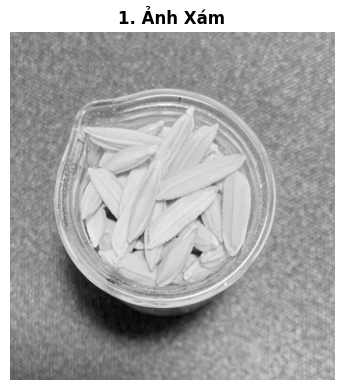

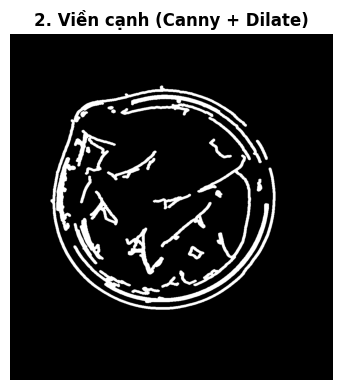

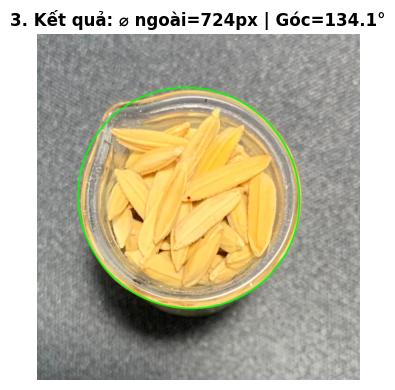


──────────────────────────────────────────────
  QUY ĐỔI KÍCH THƯỚC (Hiệu chỉnh)
──────────────────────────────────────────────
  Đường kính ngoài quy đổi : 0.55 cm (tính cả thành)
  Tỷ lệ quy đổi            : 1328.44 px/cm
  Chiều cao khối lúa (px)  : 447.68 px
  Thể tích khối lúa (px³)  : 13,046,138.31 px³
──────────────────────────────────────────────


────────────────────────────────────────
  pixels_per_cm      : 1328.4404 px/cm
  Thể tích px³       : 13,046,138 px³
  Thể tích hình trụ  : 0.01 cm³
  Thể tích hiệu dụng : 0.00 cm³  (x0.62)
────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BƯỚC 2: SAHI SEGMENTATION — CẮT POLYGON TỪNG HẠT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Performing prediction on 4 slices.
Tìm thấy 4 đối tượng. Đang xử lý cắt ảnh...
Hoàn tất! Kết quả lưu tại: /content/crops
Tổng số polygon đã cắt: 4 hạt

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BƯỚC 3: CNN PHÂN LOẠI → 3 THƯ MỤC CON
━━━━━━━━━━━

In [12]:
import os
import shutil
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────────────────
# NHẬP THÔNG SỐ ĐẦU VÀO — CHỈ CẦN CHỈNH PHẦN NÀY
# ─────────────────────────────────────────────────────────────────────────────
IMAGE_PATH          = "/content/test12.jpg"
CYLINDER_DIAM_CM    = 0.145   # Đường kính trong vật chứa (cm)
CYLINDER_HEIGHT_CM  = 0.337   # Chiều cao toàn bộ vật chứa (cm)
EMPTY_CM            = 0    # Khoảng trống từ miệng hũ đến mặt lúa (cm)
PACKING_FRACTION    = 0.62   # Hệ số chèn lấp (~0.60–0.64 cho hạt lúa)

OUTPUT_CROP_DIR     = "/content/crops"          # Thư mục lưu polygon gốc từ SAHI
OUTPUT_CLASSIFIED   = "/content/crops_classified"  # Thư mục gốc chứa 3 thư mục con

UNIFORMITY_THRESHOLD = 0.80  # 80% hạt phải nằm trong dải chuẩn

# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 1 — Quy đổi kích thước & tính thể tích khối lúa
# ─────────────────────────────────────────────────────────────────────────────
print("━" * 50)
print("  BƯỚC 1: QUY ĐỔI KÍCH THƯỚC & THỂ TÍCH KHỐI LÚA")
print("━" * 50)

pixels_per_cm, rice_volume_px3, container_w_px, rice_height_px = cell_1_pipeline(
    image_path = IMAGE_PATH,
    diam_cm    = CYLINDER_DIAM_CM,
    height_cm  = CYLINDER_HEIGHT_CM,
    empty_cm   = EMPTY_CM,
)

# Thể tích thực (cm³) từ thông số nhập tay
rice_height_cm     = CYLINDER_HEIGHT_CM - EMPTY_CM
cylinder_vol_cm3   = math.pi * (CYLINDER_DIAM_CM / 2) ** 2 * rice_height_cm
effective_vol_cm3  = cylinder_vol_cm3 * PACKING_FRACTION

print(f"\n{'─'*40}")
print(f"  pixels_per_cm      : {pixels_per_cm:.4f} px/cm")
print(f"  Thể tích px³       : {rice_volume_px3:,.0f} px³")
print(f"  Thể tích hình trụ  : {cylinder_vol_cm3:,.2f} cm³")
print(f"  Thể tích hiệu dụng : {effective_vol_cm3:,.2f} cm³  (x{PACKING_FRACTION})")
print(f"{'─'*40}\n")

# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 2 — SAHI segmentation → cắt polygon từng hạt
# ─────────────────────────────────────────────────────────────────────────────
print("━" * 50)
print("  BƯỚC 2: SAHI SEGMENTATION — CẮT POLYGON TỪNG HẠT")
print("━" * 50)

sahi_result = run_sahi_segmentation(
    yolo_model_path  = YOLO_MODEL_PATH,
    image_path        = IMAGE_PATH,
    output_crop_dir  = OUTPUT_CROP_DIR,
    confidence       = 0.9,
)

crop_files = [f for f in os.listdir(OUTPUT_CROP_DIR) if f.lower().endswith(".png")]
print(f"Tổng số polygon đã cắt: {len(crop_files)} hạt\n")

# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 3 — CNN phân loại → lưu vào 3 thư mục con
# ─────────────────────────────────────────────────────────────────────────────
print("━" * 50)
print("  BƯỚC 3: CNN PHÂN LOẠI → 3 THƯ MỤC CON")
print("━" * 50)

# Tạo lại cấu trúc thư mục classified sạch
if os.path.exists(OUTPUT_CLASSIFIED):
    shutil.rmtree(OUTPUT_CLASSIFIED)

label_dirs = {
    "hat_nguyen"     : os.path.join(OUTPUT_CLASSIFIED, "hat_nguyen"),
    "hat_khuyet_tat" : os.path.join(OUTPUT_CLASSIFIED, "hat_khuyet_tat"),
    "undefined"      : os.path.join(OUTPUT_CLASSIFIED, "undefined"),
}
for d in label_dirs.values():
    os.makedirs(d)

counts = {"hat_nguyen": 0, "hat_khuyet_tat": 0, "undefined": 0}

print(f"Đang phân loại {len(crop_files)} hạt...")
for fname in crop_files:
    src_path = os.path.join(OUTPUT_CROP_DIR, fname)
    img_bgra = cv2.imread(src_path, cv2.IMREAD_UNCHANGED)
    if img_bgra is None: continue
    if img_bgra.shape[2] == 4:
        crop_bgr = img_bgra[:, :, :3].copy()
        alpha    = img_bgra[:, :, 3]
        crop_bgr[alpha == 0] = [0, 0, 0]
    else:
        crop_bgr = img_bgra
    label = predict_cnn(crop_bgr)
    dst_path = os.path.join(label_dirs[label], fname)
    shutil.copy2(src_path, dst_path)
    counts[label] += 1

n_total_detected = sum(counts.values())
print(f"\n Kết quả phân loại CNN:")
print(f"Hạt nguyên      : {counts['hat_nguyen']:>5}  ({counts['hat_nguyen']/max(n_total_detected,1)*100:.1f}%)")
print(f"Hạt khuyết tật  : {counts['hat_khuyet_tat']:>5}  ({counts['hat_khuyet_tat']/max(n_total_detected,1)*100:.1f}%)")
print(f"Undefined        : {counts['undefined']:>5}  ({counts['undefined']/max(n_total_detected,1)*100:.1f}%)")
print(f"Tổng             : {n_total_detected:>5}\n")

# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 4 — Lấy kích thước (diện tích + thể tích) từ thư mục hat_nguyen
# ─────────────────────────────────────────────────────────────────────────────
print("━" * 50)
print("  BƯỚC 4: ĐO KÍCH THƯỚC HẠT NGUYÊN")
print("━" * 50)
nguyen_dir = label_dirs["hat_nguyen"]
if counts["hat_nguyen"] == 0:
    raise RuntimeError("Không có hạt nguyên nào để phân tích!")

volumes_px3_list = []
for fname in os.listdir(nguyen_dir):
    if not fname.lower().endswith(".png"): continue
    fpath = os.path.join(nguyen_dir, fname)
    try:
        metrics, _ = process_grain(fpath, label="hat_nguyen")
        volumes_px3_list.append(metrics["vol_px3"])
    except Exception: continue

print(f"Đã đo {len(volumes_px3_list)} hạt nguyên")

# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 5 — Đánh giá độ đồng đều
# ─────────────────────────────────────────────────────────────────────────────
uniformity = evaluate_batch_uniformity(volumes_px3_list, threshold_rate=UNIFORMITY_THRESHOLD)

# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 6 — Ước tính
# ─────────────────────────────────────────────────────────────────────────────
median_vol_px3 = float(np.median(volumes_px3_list)) if volumes_px3_list else 1.0
mean_vol_px3   = float(np.mean(volumes_px3_list))   if volumes_px3_list else 1.0
median_vol_cm3 = median_vol_px3 / (pixels_per_cm ** 3)
mean_vol_cm3   = mean_vol_px3   / (pixels_per_cm ** 3)
est_total       = int(effective_vol_cm3 / median_vol_cm3)

ratio_nguyen    = counts["hat_nguyen"]     / max(n_total_detected, 1)
ratio_khuyet    = counts["hat_khuyet_tat"] / max(n_total_detected, 1)
ratio_undef     = counts["undefined"]      / max(n_total_detected, 1)

est_nguyen      = int(est_total * ratio_nguyen)
est_khuyet      = int(est_total * ratio_khuyet)
est_undef       = int(est_total * ratio_undef)

n_classified    = counts["hat_nguyen"] + counts["hat_khuyet_tat"]
quality_rate    = counts["hat_nguyen"] / max(n_classified, 1) * 100
defect_rate     = counts["hat_khuyet_tat"] / max(n_classified, 1) * 100

grade_text = "ĐẠT — TỐT" if quality_rate >= 90 else "ĐẠT — TRUNG BÌNH" if quality_rate >= 75 else "KHÔNG ĐẠT — KÉM"

# ─────────────────────────────────────────────────────────────────────────────
# KẾT LUẬN TỔNG HỢP (Đã loại bỏ icon/emoji)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "━" * 50)
print("  KẾT LUẬN PHÂN TÍCH HẠT LÚA")
print("━" * 50)

print("\nThông số vật chứa")
print(f"    Đường kính          : {CYLINDER_DIAM_CM:.4f} cm")
print(f"    Chiều cao           : {CYLINDER_HEIGHT_CM:.4f} cm")
print(f"    Thể tích hình trụ   : {cylinder_vol_cm3:,.4f} cm³")
print(f"    Thể tích hiệu dụng  : {effective_vol_cm3:,.4f} cm³")

print(f"\nĐếm trực tiếp trên ảnh (tổng {n_total_detected} hạt)")
print(f"    Hạt nguyên          : {counts['hat_nguyen']:,} ({ratio_nguyen*100:.1f}%)")
print(f"    Hạt khuyết tật      : {counts['hat_khuyet_tat']:,} ({ratio_khuyet*100:.1f}%)")

print(f"\nThống kê thể tích hạt nguyên")
print(f"    Median (cm³)        : {median_vol_cm3:.6f} cm³")
print(f"    Độ đồng đều         : {uniformity['ty_le_dat']:.2f}% — {'ĐẠT' if uniformity['ket_qua'] else 'KHÔNG ĐẠT'}")

print(f"\nƯớc tính tổng số hạt trong hũ")
print(f"    Tổng                : {est_total:,} hạt")
print(f"    Hạt nguyên          : {est_nguyen:,} hạt")
print(f"    Hạt khuyết tật      : {est_khuyet:,} hạt")

print(f"\nĐánh giá chất lượng")
print(f"    Tỷ lệ hạt nguyên    : {quality_rate:.1f}%")
print(f"    Kết quả             : {grade_text}")
print("\n" + "━" * 50)

# VISUALIZATION
if len(volumes_px3_list) > 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(volumes_px3_list, bins=20, color='#2196F3', edgecolor='white')
    axes[0].set_title("Phân phối thể tích")
    axes[0].grid(True, alpha=0.3)
    axes[1].pie([counts['hat_nguyen'], counts['hat_khuyet_tat'], counts['undefined']],
                 labels=['Nguyên', 'Khuyết tật', 'Undefined'], autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Tỷ lệ phân loại")
    plt.tight_layout()
    plt.show()